In [ ]:
import os
current_dir = os.path.basename(os.getcwd())
if not current_dir.startswith('show-and-tell'):
    os.chdir('..')

In [2]:
import torch
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import data_utils
import cbm
from skimage.transform import resize
from demo_utils import bar
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load image and get model prediction

In [3]:
load_dir = "models/imagenet"
device = "cpu"
dataset = "imagenet"
backbone = "resnet50_imagenet"
target_preprocess = data_utils.get_resnet_imagenet_preprocess
model = cbm.load_cbm(load_dir, backbone, device)

In [4]:
cls_file = data_utils.LABEL_FILES[dataset]

with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

In [5]:
from torchvision import transforms
path = 'demos/images/ILSVRC2012_val_00038513_n06874185.JPEG'

def get_resnet_imagenet_preprocess():
    target_mean = [0.485, 0.456, 0.406]
    target_std = [0.229, 0.224, 0.225]
    preprocess = transforms.Compose([transforms.Resize((224,224)),
                   transforms.ToTensor(), transforms.Normalize(mean=target_mean, std=target_std)])
    return preprocess

image = cv2.imread(path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
preprocess = get_resnet_imagenet_preprocess()
proc_image = preprocess(Image.fromarray(image))

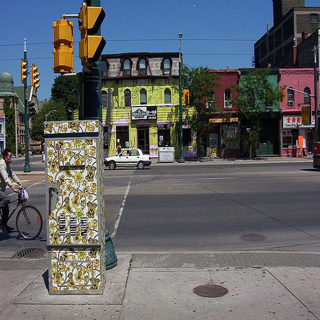

True class: traffic light
1st Pred: parking meter, 11.400
2nd Pred: traffic light, 10.463
3rd Pred: gas pump, 9.294


In [6]:
with torch.no_grad():

    # Preprocess and display image
    input_tensor = proc_image.unsqueeze(0).to(device)
    display(Image.fromarray(image).resize((320, 320)))
    
    # Get top 3 predictions
    outputs, concept_activations, concept_maps = model(input_tensor)
    top_logit_vals, top_classes = torch.topk(outputs[0], k=3)
    confidences = torch.nn.functional.softmax(outputs[0], dim=0)
    print("True class: traffic light")
    print("1st Pred: {}, {:.3f}".format(classes[top_classes[0]], top_logit_vals[0]))
    print("2nd Pred: {}, {:.3f}".format(classes[top_classes[1]], top_logit_vals[1]))
    print("3rd Pred: {}, {:.3f}".format(classes[top_classes[2]], top_logit_vals[2]))

## Select a region of interest (ROI) in the image

In [7]:
from demo_utils import RegionSelector
%matplotlib widget

### Instructions
Select the region around the traffic lights
1. Use your mouse to select a polygon around the traffic lights
2. Click to add points that enclose this region
3. When done - press Enter to see the selected ROI on the image
4. Click the 'Finish' button (bottom right)

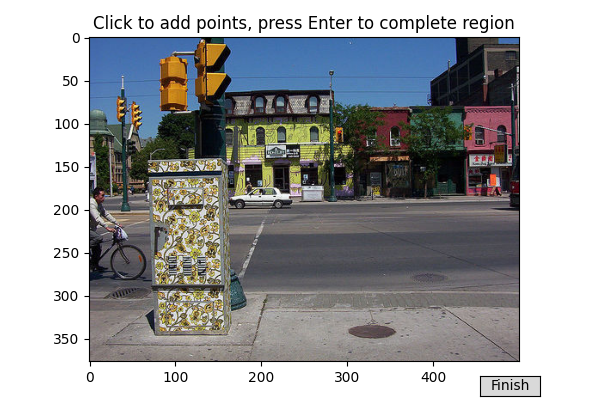

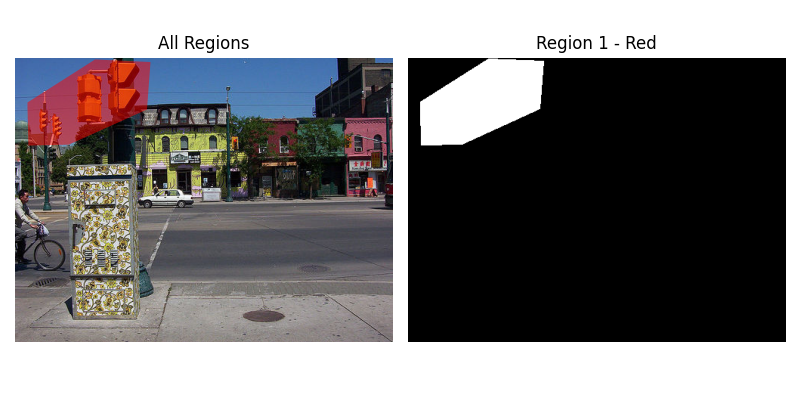

In [8]:
path = 'demos/images/ILSVRC2012_val_00038513_n06874185.JPEG'
selector = RegionSelector(path)
masks = selector.get_masks()

## Explain ROI

Ask the model to explain what concepts it recognizes within the ROI

In [9]:
plt.close("all")
%matplotlib inline

In [10]:
# join selected regions into a single mask
roi_mask = np.logical_or.reduce(masks).astype(np.uint8)

# alternatively, you can use a pre-defined ROI mask
# roi_mask = np.load('demos/roi_mask.npy')

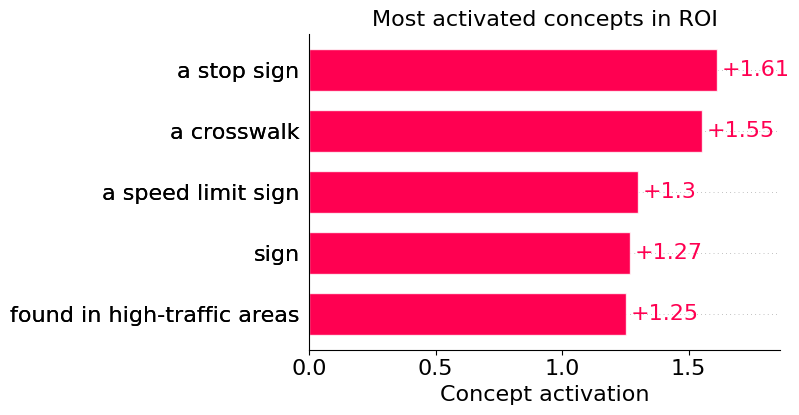

<Figure size 640x480 with 0 Axes>

In [11]:
with torch.no_grad():
    
    # Compute and dispaly concept activations in ROI
    concept_act_roi = np.zeros_like(concept_activations)
    for i in range(concept_activations.shape[1]):
        concept_map = concept_maps[0, i].cpu().numpy()
        resized_map = resize(concept_map, (224, 224), order=1, mode='reflect', anti_aliasing=True)
        resized_roi = resize(roi_mask, (224, 224))
        concept_act_roi[0, i] = np.mean(resized_map[resized_roi > 0])
    contributions = concept_act_roi[0]
    feature_names = [
        ("NOT " if val < 0 else "") + concepts[i]
        for i, val in enumerate(contributions)
    ]
    
    max_display = min(np.count_nonzero(np.abs(contributions) > 0.005) + 1, 5)
    title = "Most activated concepts in ROI"
    bar(contributions, feature_names, max_display=max_display, title=title, fontsize=16)

    plt.show()
    plt.tight_layout()


## User Intervention

Step 1: Identify concepts that are connected the true class, but are not highly activated in the selected ROI

In [12]:
to_show = [classes.index("traffic light")]

for i in to_show:
    print("Concepts connected to output class - {}:".format(classes[i]))
    for j in range(len(concepts)):
        if torch.abs(model.final.weight[i,j])>0.05:
            print("{}, activation in ROI = {:.3f}".format(concepts[j], contributions[j]))

Concepts connected to output class - traffic light:
a crossing guard, activation in ROI = 1.183
a flashing light, activation in ROI = 1.075
a signal, activation in ROI = 1.086
a stop, activation in ROI = 1.130
a stop button, activation in ROI = 1.082
a stop sign, activation in ROI = 1.611
an on/off switch, activation in ROI = 0.844
buttons on the side or face, activation in ROI = 0.501
lights or LEDs, activation in ROI = 0.998
lots of machinery, activation in ROI = 0.317
the ability to change color, activation in ROI = 0.431


We will select to locally increase the activation of `["lights or LEDs", "the ability to change color"]` concepts

In [13]:
# Intervention parameters:
concepts_to_edit = ["lights or LEDs", "the ability to change color"]
correction_factors = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
concepts_idx = [concepts.index(concept) for concept in concepts_to_edit]
print("Increasing concept activations:", concepts_to_edit, "within the selected ROI")

Increasing concept activations: ['lights or LEDs', 'the ability to change color'] within the selected ROI


Step 2: Gradually increase concept activations within the selected ROI and examine how the model's predictions change

In [14]:
k = 3
top_logits = np.zeros((len(correction_factors), k))
top_class_names = []

for i, beta in enumerate(correction_factors):
    print("Increasing concepts by:", beta)
    with torch.no_grad():
        x = proc_image
        x = x.unsqueeze(0).to(device)
        
        intervention_maps = np.zeros_like(concept_maps)
        # increase 1st concept activation
        intervention_maps[0,concepts_idx[0],:,:] = beta * (resize(masks[0], intervention_maps.shape[-2:], order=1, mode='reflect', anti_aliasing=True) > 0).astype(np.float32)
        # decrease 2nd concept activation
        intervention_maps[0,concepts_idx[1],:,:] = beta * (resize(masks[0], intervention_maps.shape[-2:], order=1, mode='reflect', anti_aliasing=True) > 0).astype(np.float32)
        outputs, concept_act, concept_maps = model(x, intervention_maps)
        
        top_logit_vals, top_classes = torch.topk(outputs[0], dim=0, k=k)
        conf = torch.nn.functional.softmax(outputs[0], dim=0)
        print("1st Pred:{}, {:.3f}, 2nd Pred:{}, {:.3f}, 3rd Pred:{}, {:.3f}".format(classes[top_classes[0]], top_logit_vals[0],
                                                                        classes[top_classes[1]], top_logit_vals[1],
                                                                        classes[top_classes[2]], top_logit_vals[2]))
        top_logits[i,:] = np.array([top_logit_vals[0].item(), top_logit_vals[1].item(), top_logit_vals[2].item()])
        top_class_names.append([classes[top_classes[0]], classes[top_classes[1]], classes[top_classes[2]]])

Increasing concepts by: 0.0
1st Pred:parking meter, 11.400, 2nd Pred:traffic light, 10.463, 3rd Pred:gas pump, 9.294
Increasing concepts by: 0.2
1st Pred:parking meter, 11.400, 2nd Pred:traffic light, 10.561, 3rd Pred:gas pump, 9.294
Increasing concepts by: 0.4
1st Pred:parking meter, 11.400, 2nd Pred:traffic light, 10.682, 3rd Pred:gas pump, 9.294
Increasing concepts by: 0.6
1st Pred:parking meter, 11.400, 2nd Pred:traffic light, 10.827, 3rd Pred:gas pump, 9.294
Increasing concepts by: 0.8
1st Pred:parking meter, 11.400, 2nd Pred:traffic light, 10.997, 3rd Pred:gas pump, 9.294
Increasing concepts by: 1.0
1st Pred:parking meter, 11.400, 2nd Pred:traffic light, 11.192, 3rd Pred:gas pump, 9.294
Increasing concepts by: 1.2
1st Pred:traffic light, 11.410, 2nd Pred:parking meter, 11.400, 3rd Pred:gas pump, 9.294
Increasing concepts by: 1.4
1st Pred:traffic light, 11.648, 2nd Pred:parking meter, 11.400, 3rd Pred:gas pump, 9.294
Increasing concepts by: 1.6
1st Pred:traffic light, 11.904, 2nd 

In [15]:
print("New predicted class: {}".format(classes[top_classes[0]]))

New predicted class: traffic light
